<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br><br><br>

# Listed Volatility and Variance Derivatives

**Wiley Finance (2017)**

Dr. Yves J. Hilpisch | The Python Quants GmbH

http://tpq.io | [@dyjh](http://twitter.com/dyjh) | http://books.tpq.io

<img src="https://hilpisch.com/images/lvvd_cover.png" alt="Listed Volatility and Variance Derivatives" width="30%" align="left" border="0">

# Model-Free Replication of Variance

## Introduction

Although volatility derivatives, variance swaps and futures are considered second generation derivatives (since they are defined on volatility and variance directly), some of the most elegant and robust results of quantitative finance apply to these kinds of derivatives. In particular, it is possible to statically replicate realized variance without using any kind of specific model. This, for example, does not apply to most other important concepts in option pricing and trading, like implied volatility or delta hedging of options.

This chapter covers mainly the following topics:

* **spanning with options**: Breeden and Litzenberger (1978) already in the 1970s showed how to replicate state-contingent payoffs (satisfying certain conditions) by using positions in options
* **log contracts**: an important piece in the replication of (realized) variance and the valuation of variance swaps are so-called log contracts
* **static replication of variance**: this is about the central result of replicating realized variance by a log contract as well as static positions in options
* **derivatives with constant dollar gamma**: in the replication and valuation of variance swaps, constant dollar gamma positions play a central role
* **practical replication of variance swaps**: using the theoretical insights and results, the chapter also illustrates the generation of constant dollar gamma positions and therewith the practical replication of variance swaps based on numerical examples
* **VSTOXX as volatility index**: using the central result, the final section in this chapter explains and justifies the definition of the VSTOXX volatility index (and the VIX index to this end)

The theoretical parts of this chapter roughly follow the lines of chapter 11 of Gatheral (2006). Since they are of importance for both volatility and variance derivatives we have put them up front and present them in a connected fashion.

## Spanning with Options

Breeden and Litzenberger (1978) use option prices to derive prices for *elementary securities*, i.e. securities that pay exactly 1 unit of currency at a certain future date given a certain state of the economy. In economics, *Arrow-Debreu security* is also a common term. The prices of elementary securities are generally called *state prices*. Having state prices available, every other contingent claim can be priced by multiplying the contingent claim's state-dependent payoff by the respective state prices.

Let $t \geq 0$ denote the current date and $T>t$ the future date of interest (e.g. maturity of a derivative instrument). For simplicity, states of the economy should be distinguished by the level of a stock index $S$ only. Let $p(S_{T},T;S_{t},t)$ denote the *state price* given a stock index level of $S_{t}$ at $t$ for a stock index level $S_{T}$ at $T$, then:

$$
p(S_{T},T;S_{t},t)=\left. \frac{\partial^{2} P(S_{t},K,T)}{\partial K^{2}}\right|_{S_{T}=K}=\left. \frac{\partial^{2} C(S_{t},K,T)}{\partial K^{2}}\right|_{S_{T}=K}
$$

Here, $P$ and $C$ represent prices (given by some pricing formula) of European put and call options, respectively. Therefore, a state price can be derived by taking the second partial derivative of an option pricing formula with respect to the strike of the option. Equipped with these state prices, the value of a state-contingent claim with payoff function $g(S_{T})$ is

\begin{eqnarray}
\mathbf{E}_{t}(g(S_{T})|S_{t})&=& \int_{0}^{\infty}g(K)p(K,T;S_{t},t)dK\nonumber \\
&=&\int_{0}^{F} g(K) \frac{\partial^{2} P(S_{t},K,T)}{\partial K^{2}} dK + \int_{F}^{\infty} g(K) \frac{\partial^{2} C(S_{t},K,T)}{\partial K^{2}} dK\nonumber
\end{eqnarray}

with $F$ being the $T$-forward price of the index at $t$ (see Breeden and Litzenberger (1978)).

We now apply integration by parts. With $u = u(x), v = v(x), du = u'(x)dx, dv=v'(x)dx$, integration by parts states that

$$
\int u(x)v'(x)dx=u(x)v(x)-\int u'(x)v(x)dx 
$$

Therefore, we get

\begin{eqnarray}
\mathbf{E}_{t}(g(S_{T})|S_{t}) &=& \left. g(K) \frac{\partial P(S_{t},K,T)}{\partial K} \right|_{0}^{F}
 - \int_{0}^{F} g'(K) \frac{\partial P(S_{t},K,T)}{\partial K} dK \nonumber \\
&+& \left. g(K) \frac{\partial C(S_{t},K,T)}{\partial K}\right|_{F}^{\infty} - \int_{F}^{\infty} g'(K) \frac{\partial C(S_{t},K,T)}{\partial K} dK\nonumber \\
&=& g(F)- \int_{0}^{F} g'(K) \frac{\partial P(S_{t},K,T)}{\partial K} dK - \int_{F}^{\infty} g'(K) \frac{\partial C(S_{t},K,T)}{\partial K} dK\nonumber
\end{eqnarray}

Applying integration by parts once again yields

\begin{eqnarray}
\mathbf{E}_{t}(g(S_{T})|S_{t})
&=& g(F) - \left. g'(K) P(S_{t},K,T)\right|_{0}^{F} + \int_{0}^{F} g''(K) P(S_{t},K,T) dK\nonumber\\
 &-& \left. g'(K) C(S_{t},K,T)\right|_{F}^{\infty} + \int_{F}^{\infty} g''(K) C(S_{t},K,T) dK \nonumber\\
 &=& g(F) + \int_{0}^{F} g''(K) P(S_{t},K,T) dK
 + \int_{F}^{\infty} g''(K) C(S_{t},K,T) dK \nonumber
\end{eqnarray}

As is evident from this last equation, in this setting any twice continuously differentiable payoff $g$ due at $T$ can be replicated by infinite strips of European put and call options maturing at $T$. In other words, these options span the space of twice continuously differentiable payoffs.

## Log Contracts

So-called *log contracts* are a kind of derivative instrument that plays an important role in the valuation of variance swaps. Recall that a long position in a variance contract pays at maturity the difference between the realized variance over the life time of the swap and an up front fixed variance strike.

Consider the payoff $g(S_{T})=\log \frac{S_{T}}{F} = \log S_T - \log F$. Then

\begin{eqnarray}
g'(S_{T})&=&\frac{1}{S_{T}}\nonumber\\
g''(S_{T})&=&-\frac{1}{S_{T}^ 2}\nonumber
\end{eqnarray}

Valuing this contract by making use of the option spanning approach yields

\begin{eqnarray}
\mathbf{E}\left(\left.\log\frac{S_{T}}{F}\right| S_{t}\right)
&=& \log\frac{F}{F} + \int_{0}^{F} -\frac{1}{K^{2}} P(S_{t},K,T) dK
 + \int_{F}^{\infty} -\frac{1}{K^{2}} C(S_{t},K,T) dK\nonumber\\
  &=& -\int_{0}^{F} P(S_{t},K,T) \frac{dK}{K^{2}}
 - \int_{F}^{\infty} C(S_{t},K,T) \frac{dK}{K^{2}} \nonumber
\end{eqnarray}

As a consequence, the log contract can be replicated by (infinite strips of) European put and call options on the underlying. Every option is weighted by the square of the strike.

## Static Replication of Realized Variance and Variance Swaps

Assume for simplicity zero short rates such that $F=S_{t}$. For $t=0$, one has 

\begin{eqnarray*}
\log\frac{S_{T}}{F}&=&\log\frac{S_{T}}{S_{0}}\nonumber\\
&=& \int_{0}^{T} d\log(S_{t})\\
&=& \int_{0}^{T} \frac{dS_{t}}{S_{t}}-\int_{0}^{T} \frac{\sigma^{2}(S_{t})}{2}dt
\end{eqnarray*}

Compare this result with those for the discrete delta hedging (chapter _Derivatives, Volatility and Variance_). Such a comparison further illustrates the connection between the (discrete) delta hedging of an option and (the valuation of) variance swaps.

Above, the fact is used that the *total return* over the interval $[0,T]$ equals the integral over the marginal returns of $S$ for the same time interval. The second term in the last equation results from the application of Itô's lemma. This term is equal to half of the total variance of $S$ over the time interval $[0,T]$. Taking the risk-neutral expectation of that expression gives

$$
\mathbf{E}\left( \int_{0}^{T}\sigma^{2}(S_{t})dt \right)= -2\mathbf{E}\left(\log\frac{S_{T}}{F} \right)
$$

Combining the results about the the log contract replication and valuation with this last insight shows that realized variance is given in a model-free manner through the prices of European put and call options. This is due to the fact that realized variance can be replicated by the use of a log contract.

## Constant Dollar Gamma Derivatives and Portfolios

Above, we establish the replication of realized variance by the log contract. The log contract has, as a defining characteristic, a *constant dollar gamma*. The *gamma* of a derivative defined on some underlying $S$ with value $f_t(S_t)$ is defined as

$$\Gamma_t = \frac{\partial^2 f_t}{\partial S_t^2}$$

i.e. the second partial derivative of the pricing function with respect to the value of the underlying (assuming that the pricing function indeed is twice continuously differentiable).

Its *dollar gamma* is then defined by the product of the gamma and the square of the value of the underlying (sometimes the factor 0.5 is added)

$$\Gamma^{\$}_t \equiv \Gamma_t \cdot S^2_t$$

Omitting the time index, a constant dollar gamma implies, for some fixed value $a$, a gamma of

\begin{eqnarray*}
\Gamma^{\$} = \Gamma \cdot S^2 &\equiv&  a \\
\Leftrightarrow \Gamma &=& \frac{a}{S^2}
\end{eqnarray*}

We therefore have 

$$
\frac{\partial^2 f}{\partial S^2} = \frac{a}{S^2}
$$

This partial differential equation has a solution of the form
$$
f(S) = a \log(S) + bS + c
$$

Indeed, the log contract fits trivially into the general solution by setting $a=1, b=0, c=0$, i.e.

$$
f(S) = \log(S)
$$

illustrating its importance.

With $\hat{\sigma}^2$ being the realized variance and $\sigma_K^2$ being the fixed variance strike, a long position in a *variance swap* (with notional of 1 currency unit), pays at expiry

$$
\hat{\sigma}^2 - \sigma_K^2
$$

With this payoff, we get a replicating portfolio of

$$
f_t(S_t) = 2 \log(S_t) + e^{-r(T-t)} \sigma_K^2
$$

i.e. $a=2, b = 0, c = e^{-r(T-t)} \sigma_K^2$. A variance swap therefore also has a constant dollar gamma. This insight is used in the next section.

## Practical Replication of Realized Variance

Consider the Black-Scholes-Merton (1973) model economy (no dividends) with the present value of a European call option given by

\begin{eqnarray*}
C(S, K, t, T, r, \sigma) &=& S_{t} \cdot \mathbf{N}(d_{1})-e^{-r(T-t)} \cdot K \cdot \mathbf{N}(d_{2}) \\
\mathbf{N}(d)&=&\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{d}e^{-\frac{1}{2}x^{2}}dx \\
d_{1}&=&\frac{\log \frac{S_{t}}{K}+(r+\frac{\sigma^{2}}{2})(T-t)}{\sigma \sqrt{T-t}} \\
d_{2}&=&\frac{\log \frac{S_{t}}{K}+(r-\frac{\sigma^{2}}{2})(T-t)}{\sigma \sqrt{T-t}}
\end{eqnarray*}

Here, $S_t$ is the index level at date $t$, $K$ is the option strike, $T$ date of maturity (in year fractions), $r$ the constant, risk-less short rate and $\sigma$ the instantaneous volatility.

The *gamma* of an option in this model is given as follows

$$\Gamma_t = \frac{\partial^2 C_t}{\partial S_t^2} = \frac{\mathbf{N}'(d_1)}{S_t \sigma \sqrt{T-t}}$$

with

$$\mathbf{N}'(d) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2} x^2}$$

Our aim in this section is to build a **portfolio of European call options** with a constant dollar gamma, i.e. $\Gamma^{Portfolio} \cdot S_t^2 \equiv a$ for some fixed value $a$.

The Python function `dollar_gamma` implements the dollar gamma formula for the European call option.

In [1]:
import math
import numpy as np
import scipy.stats as scs
def dollar_gamma(St, K, t, T, r, sigma):
    ''' Returns European call option dollar gamma. '''
    d1 = ((np.log(St / K) + (r + 0.5 * sigma ** 2) * (T - t))
              / sigma * math.sqrt(T - t))
    gamma = scs.norm.pdf(d1) / (St * sigma * math.sqrt(T - t))
    return gamma * St ** 2

Let us parametrize the financial model for $t=0$, leaving the values for the initial index level $S_0$ and for the option strike $K$ undefined for the moment.

In [2]:
t = 0.0  # curent date in year fractions
T = 1.0  # maturity in year fractions
r = 0.01  # constant risk-less short rate
sigma = 0.2  # instantenous volatility

Next, we can calculate the dollar gamma values for different strikes of the European call options over a range, respectively, of initial values for the index level.

In [3]:
import pandas as pd 
from pylab import plt, mpl
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'

In [4]:
gammas = pd.DataFrame()
## 300 data points over the range form 0 to 300
s_range = np.linspace(0.0001, 300, 300)
strike_range = range(25, 226, 25)
for K in strike_range:
    gammas['K=%d' % K] = dollar_gamma(s_range, K, t, T, r, sigma)

For every strike level gamma values for 300 different initial values of the stock index have been calculated and collected. 

In [5]:
gammas.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   K=25    300 non-null    float64
 1   K=50    300 non-null    float64
 2   K=75    300 non-null    float64
 3   K=100   300 non-null    float64
 4   K=125   300 non-null    float64
 5   K=150   300 non-null    float64
 6   K=175   300 non-null    float64
 7   K=200   300 non-null    float64
 8   K=225   300 non-null    float64
dtypes: float64(9)
memory usage: 21.2 KB


Having the data stored in a pandas ``DataFrame`` object, the results are easily visualized. From the following figure, you can see that dollar gamma is more pronounced the higher the strike of the option. A doubling of the strike leads to a doubling of the maximum dollar gamma value which is always achieved at the ATM level (see strikes 25, 50, 100, 200).

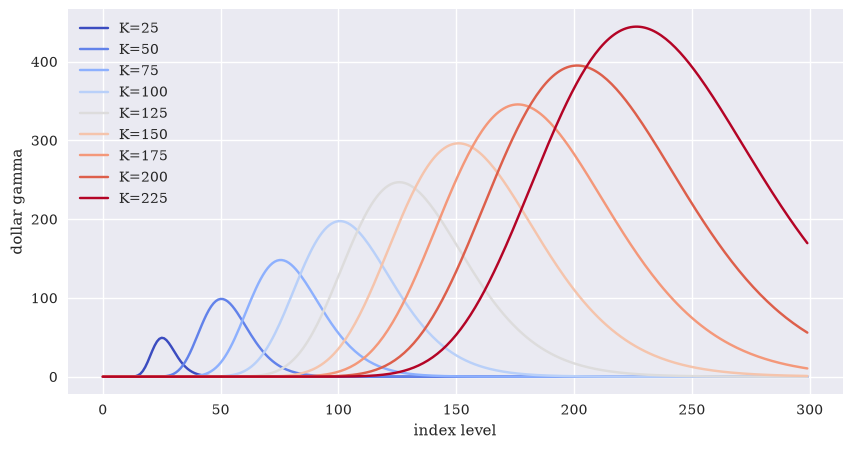

In [6]:
gammas.plot(figsize=(10, 5), cmap='coolwarm')
plt.xlabel('index level')
plt.ylabel('dollar gamma');

<p style="font-family: monospace;">Dollar gamma values for different strikes and 300 different initial stock index values.</p>

Let us check what happens when we add all dollar gamma values up by simply composing a portfolio in which every option has weight 1 or equal weight.

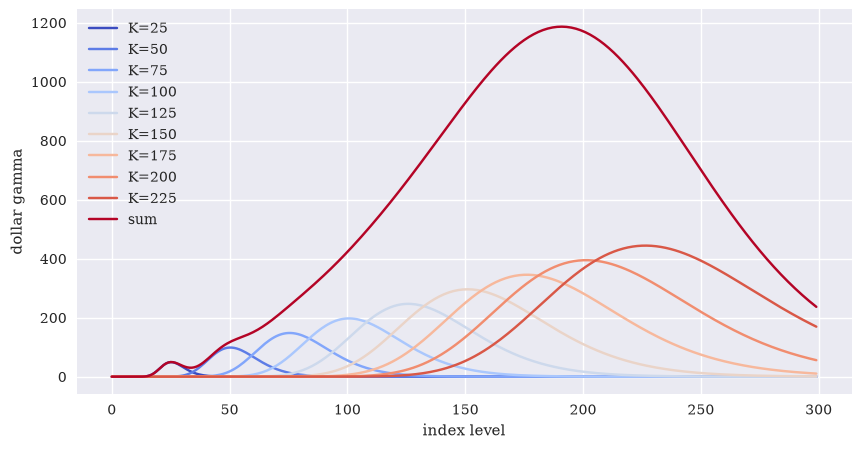

In [7]:
gammas['sum'] = gammas.sum(axis=1)
gammas.plot(figsize=(10, 5), cmap='coolwarm')
plt.xlabel('index level')
plt.ylabel('dollar gamma');

<p style="font-family: monospace;">Dollar gamma values added over the range of 300 different initial index levels.</p>

Obviously, given the previous figure, the dollar gamma of the portfolio of equally weighted options is all but constant. Let us try a different weighting scheme that attaches a higher weight to smaller strikes and a lower weight to higher strikes. To this end, we divide all dollar gamma values by the strike *K*. This brings all maximum dollar gamma values in line (to two in this case).

In [8]:
gammas_k = pd.DataFrame()
for K in strike_range:
    gammas_k['K=%d' % K] = dollar_gamma(s_range, K, t, T, r, sigma) / K
gammas_k['sum'] = gammas_k.sum(axis=1)

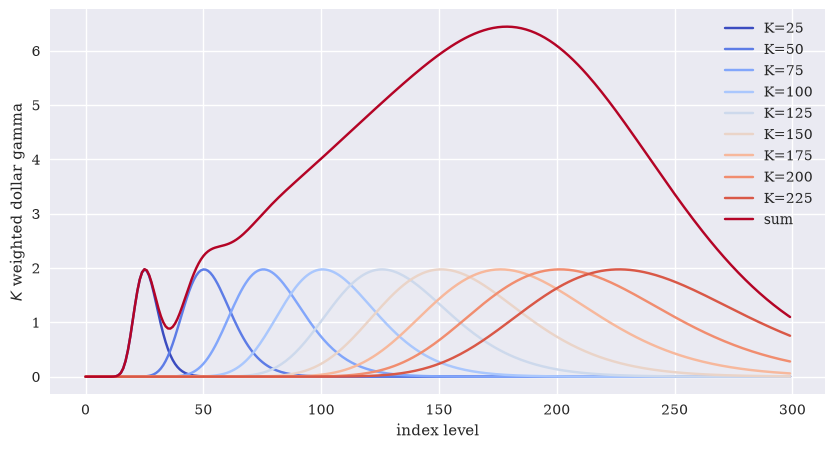

In [9]:
gammas_k.plot(figsize=(10, 5), cmap='coolwarm')
plt.xlabel('index level')
plt.ylabel('$K$ weighted dollar gamma');

<p style="font-family: monospace;">Strike-weighted, added Dollar Gamma values.

According to the previous figure this seems to be a bit better in the sense that we still do not have a constant dollar gamma but at least a range where dollar gamma is linear (mainly between strikes of 75 and 150).  Therefore, let us  weight the dollar gammas by the square of the strike (something we have already seen in the replication result for log contract). In this case the highest dollar gamma values are observed for the lowest strikes and vice versa.

In [10]:
gammas_k2 = pd.DataFrame()
for K in strike_range:
    gammas_k2['K=%d' % K] = dollar_gamma(s_range, K, t, T, r, sigma) / K ** 2
gammas_k2['sum'] = gammas_k2.sum(axis=1)

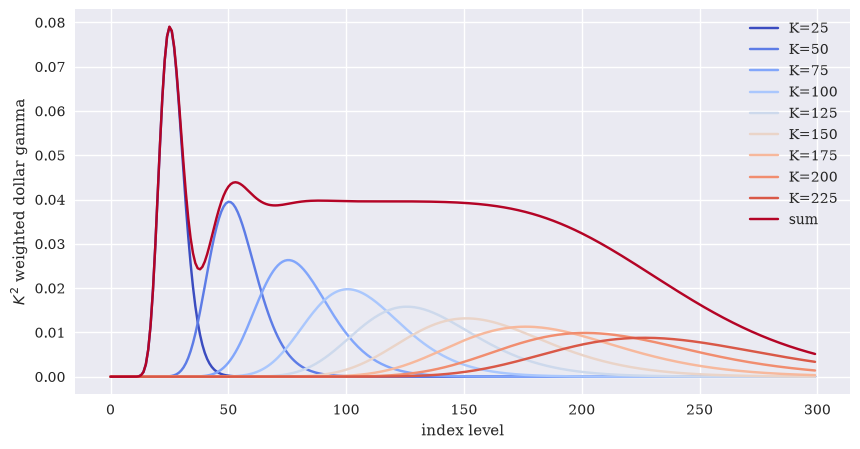

In [11]:
gammas_k2.plot(figsize=(10, 5), cmap='coolwarm')
plt.xlabel('index level')
plt.ylabel('$K^2$ weighted dollar gamma');

<p style="font-family: monospace;">Squared strike-weighted, added Dollar Gamma values.

As the previous figure shows, this approach finally yields a constant dollar gamma value between strikes of 75 and 150 at least. Let us have a final look at a more dense grid of option strikes since the theoretical result is based on infinite strips of options. The graphical output is shown in the following figure.

In [12]:
## more dense strike range
strike_range = range(10, 350, 5)
gammas_k2 = pd.DataFrame()
for K in strike_range:
    gammas_k2['K=%d' % K] = dollar_gamma(s_range, K, t, T, r, sigma) / K ** 2
gammas_k2['sum'] = gammas_k2.sum(axis=1)

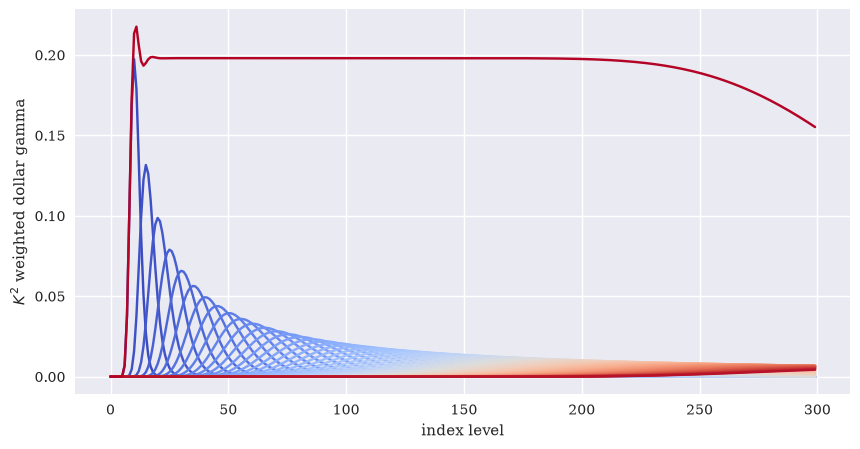

In [13]:
gammas_k2.plot(figsize=(10, 5), legend=False,
              cmap='coolwarm')
plt.xlabel('index level')
plt.ylabel('$K^2$ weighted dollar gamma');

<p style="font-family: monospace;">Strike-weighted, added Dollar Gamma values.

This numerical example shows a constant dollar gamma over a much wider range from about 25 to beyond 200. This further supports the theoretical result and the replication approach.

## VSTOXX as Volatility Index

The VSTOXX volatility index measures the implied total variance across all options written on the EURO STOXX 50 stock index for a given time-to-maturity. Another interpretation is that the VSTOXX gives the fair variance swap rate for a variance swap with the respective maturity. The major index with symbol `V2TX` has a fixed time-to-maturity of 30 days and is calculated by the interpolation of two sub-indexes. Sub-indexes are calculated for a number of fixed maturity dates.

Assume now the following setting. Given are the discounted, i.e. time $t$, prices $C_i, i=0,...,n,$ of a series of European call options on the EURO STOXX 50 stock index with fixed time-to-maturity $T$ and strike prices $K_i, i=0,...,n,$ as well as the discounted prices $P_i, i=0,...,n,$ of a series of European put options with the same time-to-maturity and strike prices. Let further hold $K_i < K_{i+1}$ for all $i \in \{0,....,n-1\}$. 

The value of the VSTOXX (sub-)index $V$ at $t=0$ is defined by

$$
V \equiv 100\cdot\sqrt{\hat{\sigma}^2}
$$

where

$$
 \hat{\sigma}^2 \equiv \frac{2}{T} \sum_{i=0}^n \frac{\Delta K_i}{{K_i}^2} e^{rT} M_i - \frac{1}{T}\left( \frac{F}{K_*}-1\right)^2
$$

with

\begin{eqnarray}
\Delta K_i &=& \left\{
\begin{array}{ll} K_1-K_0, & \mbox{for } i=0 \nonumber\\
         \frac{K_{i+1}-K_{i-1}}{2}, &  \mbox{for } i = 1,...,n-1\\      
         K_n-K_{n-1}, & \mbox{for } i=n \end{array}
         \right.  \nonumber\\ 
 F 	    &=& K_j+ e^{rT}|C_j-P_j|,  \mbox{ where } j=\displaystyle \min_{i \in \{0,...,n\}}\{|C_i-P_i|\} \nonumber\\
K_*     &=& \displaystyle \max_{ K_{i}, i \in \{0,...,n\}} \{K_i < F \} \nonumber\\
M_i &=& \left\{
	\begin{array}{ll} P_i, & \mbox{for } K_i<K_* \\ 
	\frac{P_i+C_i}{2}, &  \mbox{for } K_i=K_*\\ 
	C_i, & \mbox{for } K_i>K_* \end{array} \right. \nonumber 
\end{eqnarray}


and $r$ the constant risk-free short rate appropriate for time-to-maturity $T$.

**Erratum (2026-09-06):** the original printing defines $M_i = (P_i - C_i)/2$ at $K_i = K_*$. 
This is an error. The strip integrand $M$ is an option *price* — see the derivation below, where the 
$P - C$ difference appears only as the separate correction integral $\int_{K_*}^F e^{-rT}[K-F] \frac{dK}{K^2}$, 
approximated by the $(F/K_* - 1)^2$ term — so at $K_*$ the call and put prices must be *averaged*: 
$M_i = (P_i + C_i)/2$. This also matches the CBOE VIX/VSTOXX methodology ("the $K_0$ put and call 
prices are averaged to produce a single value", Cboe Volatility Index Methodology, p. 9). With 
$(P_i - C_i)/2$ the ATM leg even vanishes whenever $F$ falls exactly on a strike, since 
$P(F) - C(F) = 0$ by put-call parity.

It is to be shown that the defining equation for $\hat{\sigma}^2$ is indeed a valid approximation for total variance. To this end, we combine the above equations for the log contract and the total variance to obtain

\begin{eqnarray}
\hat{\sigma}^2 &=& -2\cdot\left(-\int_{0}^{F} P(S_{t},K,T) \frac{dK}{K^{2}}
 - \int_{F}^{\infty} C(S_{t},K,T) \frac{dK}{K^{2}} \right)\cdot e^{rT} \nonumber\\
\Leftrightarrow \frac{\hat{\sigma}^2 T}{2e^{rT}} &=& \int_{0}^{F} P(S_{t},K,T) \frac{dK}{K^{2}}
+ \int_{F}^{\infty} C(S_{t},K,T) \frac{dK}{K^{2}} \nonumber\\
&=& \int_{0}^{K_*} P(S_{t},K,T) \frac{dK}{K^{2}}
+ \int_{K_*}^{\infty} C(S_{t},K,T) \frac{dK}{K^{2}}\nonumber\\
&+& \int_{K_*}^{F} \left[P(S_{t},K,T)-C(S_{t},K,T)\right] \frac{dK}{K^{2}}\nonumber\\
&=& \int_{0}^{\infty} M(S_{t},K,T) \frac{dK}{K^{2}}+ \int_{K_*}^{F}e^{-rT} \left[K-F\right] \frac{dK}{K^{2}}\nonumber
\end{eqnarray}

The last term follows from the observation that only the call option is in-the-money, i.e. $e^{-rT}[F-K]>0$, given the integration boundaries. Then

\begin{eqnarray}
\hat{\sigma}^2 &=& \frac{2}{T} \int_{0}^{\infty} e^{rT} M(S_{t},K,T) \frac{dK}{K^{2}}+ \frac{2}{T} \frac{1}{K_*^{2}}  \int_{K_*}^{F} \left[K-F\right]dK\nonumber\\
&=& \frac{2}{T} \int_{0}^{\infty} e^{rT} M(S_{t},K,T) \frac{dK}{K^{2}} - \frac{1}{T} \frac{(K_*-F)^2}{K_*^{2}}\nonumber
\end{eqnarray}

Note that

\begin{eqnarray}
\frac{(K_*-F)^2}{K_*^2}&=&\frac{K_*^2-2K_*F+F^2}{K_*^2}\nonumber\\
&=& \frac{F^2}{K_*^2}-\frac{2F}{K_*}+1\nonumber\\
&=& \left(\frac{F}{K_*}-1\right)^2\nonumber
\end{eqnarray}

A possible discretization for the integral then is

$$
\hat{\sigma}^{2}\approx \frac{2}{T} \sum_{i=0}^{n} \frac{\Delta K_{i}}{K_{i}^{2}} e^{rT} M_i  - \frac{1}{T} \left( \frac{F}{K_*}-1 \right)^2
$$

giving the defining equation for $\hat{\sigma}^2$.

The calculation of implied volatilities, or variances, naturally relies on some option pricing model, like the one of Black-Scholes-Merton (1973). By contrast, the VSTOXX and VIX volatility index calculation only takes as input market-observed options prices. This is possible since realized variance at a given future date can be replicated by strips of European call and put prices maturing at the same date. The realized volatility can then be extracted by taking the square root of the realized variance. The calculation of the VSTOXX and VIX avoids a "model-bias" and uses standard market practice for the valuation of important variance related instruments, like variance swaps.

## Conclusions

This chapter introduces the elegant theory of the model-free replication of realized variance and variance swaps which dates back at least to Breeden and Litzenberger (1978). The role of log contracts and constant dollar gamma positions is discussed. Numerical examples also illustrate how to construct constant dollar gamma options positions in practice. Finally, based on this theory the definition of the VSTOXX and VIX volatility indexes is presented and justified. Subsequent chapters draw in different ways on these cornerstones in the theory of volatility and variance modeling, measuring and trading. 

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>